In [21]:
import numpy as np
import random
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

MAX_STEPS = 5000
CELL_EMPTY, CELL_FOOD, CELL_OBSTACLE = 0, 1, 2
ACTIONS = [(-1, 0), (1, 0), (0, -1), (0, 1), (0, 0)]

In [22]:
def parse_field(filename):
    lines = open(filename).read().strip().splitlines()
    n = len(lines)
    field = np.zeros((n, n), dtype=int)
    food, obstacles = [], []
    for i, row in enumerate(lines):
        cells = row.split(',')
        for j, c in enumerate(cells):
            c = c.strip()
            if c == 'X':
                field[i, j] = CELL_FOOD
                food.append((i, j))
            elif c == '#':
                field[i, j] = CELL_OBSTACLE
                obstacles.append((i, j))
    return field, food, obstacles

In [23]:
class Ant:
    def __init__(self, start_pos):
        self.start_pos = start_pos
    
    def run(self, field, automaton, max_steps=MAX_STEPS):
        n = field.shape[0]
        x, y = self.start_pos
        path = [(x, y)]
        food_eaten = 0
        grid = field.copy()
        automaton.reset()
        total_food = np.sum(grid == CELL_FOOD)
        
        for _ in range(max_steps):
            if grid[x, y] == CELL_FOOD:
                grid[x, y] = CELL_EMPTY
                food_eaten += 1
            
            dx, dy = automaton.act(grid, x, y, n)
            nx, ny = x + dx, y + dy
            
            if not (0 <= nx < n and 0 <= ny < n):
                continue
            if grid[nx, ny] == CELL_OBSTACLE:
                continue
            
            x, y = nx, ny
            path.append((x, y))
            
            if food_eaten == total_food:
                break
        
        return food_eaten, path

In [24]:
class FiniteAutomaton:
    def __init__(self, num_states=20, sensor_type='current'):
        self.num_states = num_states
        self.state = 0
        self.sensor_type = sensor_type

        num_inputs = 3 if sensor_type == 'current' else 2
        self.transitions = np.zeros((num_states, num_inputs, 2), dtype=int)
        
        for s in range(num_states):
            for t in range(num_inputs):
                self.transitions[s, t, 0] = random.randint(0, num_states - 1)
                self.transitions[s, t, 1] = random.randint(0, 4)
    
    def reset(self):
        self.state = 0
    
    def sense(self, grid, x, y, n):
        if self.sensor_type == 'current':
            return int(grid[x, y])
        else:
            for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                nx, ny = x + dx, y + dy
                if 0 <= nx < n and 0 <= ny < n:
                    if grid[nx, ny] == CELL_FOOD:
                        return 1
            return 0
    
    def act(self, grid, x, y, n):
        cell_type = self.sense(grid, x, y, n)
        next_state, action_idx = self.transitions[self.state, cell_type]
        self.state = next_state
        return ACTIONS[action_idx]
    
    def copy(self):
        new_auto = FiniteAutomaton.__new__(FiniteAutomaton)
        new_auto.num_states = self.num_states
        new_auto.state = 0
        new_auto.sensor_type = self.sensor_type
        new_auto.transitions = self.transitions.copy()
        return new_auto
    
    def mutate(self, rate=0.15):
        num_inputs = 3 if self.sensor_type == 'current' else 2
        for s in range(self.num_states):
            for t in range(num_inputs):
                if random.random() < rate:
                    self.transitions[s, t, 0] = random.randint(0, self.num_states - 1)
                if random.random() < rate:
                    self.transitions[s, t, 1] = random.randint(0, 4)
    
    def crossover(self, other):
        child = self.copy()
        mask = np.random.rand(*self.transitions.shape) < 0.5
        child.transitions = np.where(mask, self.transitions, other.transitions)
        return child
    
    def print_transitions(self):
        print(f"\nТаблица переходов ({self.num_states} состояний, сенсор: {self.sensor_type}):")
        if self.sensor_type == 'current':
            input_names = {0: 'пусто', 1: 'еда', 2: 'препят.'}
        else:
            input_names = {0: 'нет еды рядом', 1: 'еда рядом'}
        action_names = {0: '↑', 1: '↓', 2: '←', 3: '→', 4: '•'}
        num_inputs = 3 if self.sensor_type == 'current' else 2
        for s in range(self.num_states):
            for inp in range(num_inputs):
                ns, act = self.transitions[s, inp]
                print(f"S{s}+{input_names[inp]} → S{ns}, {action_names[act]}")

In [25]:
def evaluate_fitness(automaton, field, start_pos, max_steps=MAX_STEPS):
    ant = Ant(start_pos)
    food_eaten, _ = ant.run(field, automaton, max_steps)
    return food_eaten

In [26]:
class GeneticAlgorithm:
    def __init__(self, field, start_pos, population_size=100, num_states=6,
                 mutation_rate=0.05, elite_count=5, tournament_size=4, 
                 n_jobs=-1, sensor_type='current'):
        self.field = field
        self.start_pos = start_pos
        self.population_size = population_size
        self.num_states = num_states
        self.mutation_rate = mutation_rate
        self.elite_count = elite_count
        self.tournament_size = tournament_size
        self.n_jobs = n_jobs
        self.sensor_type = sensor_type
        self.population = [FiniteAutomaton(num_states, sensor_type) for _ in range(population_size)]
        self.best_automaton = None
        self.best_fitness = -1
        self.history = []
    
    def _tournament_selection(self, fitness_scores):
        indices = random.sample(range(len(self.population)), self.tournament_size)
        best_idx = max(indices, key=lambda i: fitness_scores[i])
        return self.population[best_idx].copy()
    
    def evolve(self, generations=100, verbose=True, early_stop_threshold=None):
        total_food = np.sum(self.field == CELL_FOOD)
        for gen in range(generations):
            fitness_scores = Parallel(n_jobs=self.n_jobs, backend='loky', batch_size='auto')(
                delayed(evaluate_fitness)(auto, self.field, self.start_pos)
                for auto in self.population
            )
            best_idx = int(np.argmax(fitness_scores))
            current_best = fitness_scores[best_idx]
            
            if current_best > self.best_fitness:
                self.best_fitness = current_best
                self.best_automaton = self.population[best_idx].copy()
            
            self.history.append({'generation': gen, 'best': current_best,
                               'mean': np.mean(fitness_scores), 'std': np.std(fitness_scores)})
            
            if verbose and gen % 10 == 0:
                print(f"Gen {gen:3d}: best={current_best:3d}, mean={np.mean(fitness_scores):5.2f}")
            
            if early_stop_threshold is not None and current_best >= early_stop_threshold:
                break
            
            elite_indices = np.argsort(fitness_scores)[-self.elite_count:]
            new_population = [self.population[i].copy() for i in elite_indices]
            
            while len(new_population) < self.population_size:
                p1 = self._tournament_selection(fitness_scores)
                p2 = self._tournament_selection(fitness_scores)
                child = p1.crossover(p2)
                child.mutate(rate=self.mutation_rate)
                new_population.append(child)
            
            self.population = new_population
        
        return self.best_fitness, self.best_automaton

In [27]:
def plot_field(field, food, obstacles, path):
    fig, ax = plt.subplots(figsize=(10, 10))

    base = np.zeros_like(field)
    base[field == 1] = 1
    base[field == 2] = 0.3

    ax.imshow(base, cmap="Greens", vmin=0, vmax=1, aspect="equal")

    if food:
        fx = [p[1] for p in food]
        fy = [p[0] for p in food]
        ax.plot(fx, fy, "g.", markersize=20, label="Еда")

    if obstacles:
        ox = [p[1] for p in obstacles]
        oy = [p[0] for p in obstacles]
        ax.plot(ox, oy, "ks", markersize=8, label="Препятствия")

    if path:
        px = [p[1] for p in path]
        py = [p[0] for p in path]
        ax.plot(px, py, "r-", linewidth=2, label="Путь")
        ax.plot(px[0], py[0], "bo", markersize=10, label="Старт")
        ax.plot(px[-1], py[-1], "rs", markersize=12, label="Текущая")

    ax.set_xticks(np.arange(-0.5, field.shape[1], 1))
    ax.set_yticks(np.arange(-0.5, field.shape[0], 1))
    ax.grid(True, color="gray", linewidth=0.5, alpha=0.5)

    ax.set_xticklabels([])
    ax.set_yticklabels([])

    ax.legend(loc="upper right", fontsize=10)

    plt.tight_layout()
    plt.show()

    if path:
        print(f"Путь: {len(path)} шагов")


def plot_history(history):
    generations = [h['generation'] for h in history]
    best_scores = [h['best'] for h in history]
    mean_scores = [h['mean'] for h in history]
    plt.figure(figsize=(12, 5))
    plt.plot(generations, best_scores, 'r-', linewidth=2, label='Лучший')
    plt.plot(generations, mean_scores, 'b--', linewidth=1.5, label='Средний')
    plt.xlabel('Поколение')
    plt.ylabel('Собрано еды')
    plt.title('Прогресс эволюции')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [28]:
def run_evolution(field_file='plain.csv', start_pos=(31, 0),
                  num_states=20, population_size=500, generations=300,
                  mutation_rate=0.15, elite_count=10, tournament_size=100,
                  max_steps=5000, early_stop_threshold=None,
                  verbose=True, plot_final=True, plot_history_flag=True,
                  n_jobs=-1, seed=42, sensor_type='current'):

    random.seed(seed)
    np.random.seed(seed)
    
    field, food, obstacles = parse_field(field_file)
    total_food = len(food)
    
    print(f"Поле: {field.shape[0]}×{field.shape[1]}, еда: {total_food}, старт: {start_pos}")
    print(f"Сенсор: {sensor_type}")

    ga = GeneticAlgorithm(
        field=field,
        start_pos=start_pos,
        population_size=population_size,
        num_states=num_states,
        mutation_rate=mutation_rate,
        elite_count=elite_count,
        tournament_size=tournament_size,
        n_jobs=n_jobs,
        sensor_type=sensor_type
    )
    
    best_fitness, best_automaton = ga.evolve(
        generations=generations,
        verbose=verbose,
        early_stop_threshold=early_stop_threshold
    )
    
    ant = Ant(start_pos)
    food_eaten, path = ant.run(field, best_automaton, max_steps)
    
    print(f"\nРезультат: {food_eaten}/{total_food} еды ({food_eaten/total_food*100:.1f}%), путь: {len(path)} шагов")
    best_automaton.print_transitions()
    
    if plot_final:
        plot_field(field, food, obstacles, path=path)
    
    if plot_history_flag and ga.history:
        plot_history(ga.history)
    
    return {'food_eaten': food_eaten, 'path': path, 'automaton': best_automaton,
            'history': ga.history, 'field': field, 'food': food, 'obstacles': obstacles}

Поле: 32×32, еда: 90, старт: (31, 0)
Сенсор: current
Gen   0: best= 15, mean= 2.05
Gen  10: best= 23, mean= 8.99
Gen  20: best= 27, mean= 8.86
Gen  30: best= 33, mean=10.15
Gen  40: best= 34, mean= 9.32
Gen  50: best= 35, mean=10.20
Gen  60: best= 35, mean= 9.56
Gen  70: best= 36, mean=10.81
Gen  80: best= 37, mean=11.22
Gen  90: best= 37, mean=10.58
Gen 100: best= 37, mean= 9.80
Gen 110: best= 37, mean=10.94
Gen 120: best= 37, mean=10.91
Gen 130: best= 37, mean=10.66
Gen 140: best= 37, mean=11.36
Gen 150: best= 41, mean=11.17
Gen 160: best= 41, mean=11.42
Gen 170: best= 41, mean=11.94
Gen 180: best= 44, mean=11.57
Gen 190: best= 44, mean=12.37

Результат: 44/90 еды (48.9%), путь: 4541 шагов

Таблица переходов (34 состояний, сенсор: current):
S0+пусто → S20, ←
S0+еда → S32, •
S0+препят. → S4, ↓
S1+пусто → S11, →
S1+еда → S31, ↓
S1+препят. → S22, ←
S2+пусто → S21, ←
S2+еда → S17, ←
S2+препят. → S10, ↓
S3+пусто → S6, →
S3+еда → S29, →
S3+препят. → S18, ←
S4+пусто → S32, ←
S4+еда → S24, ←

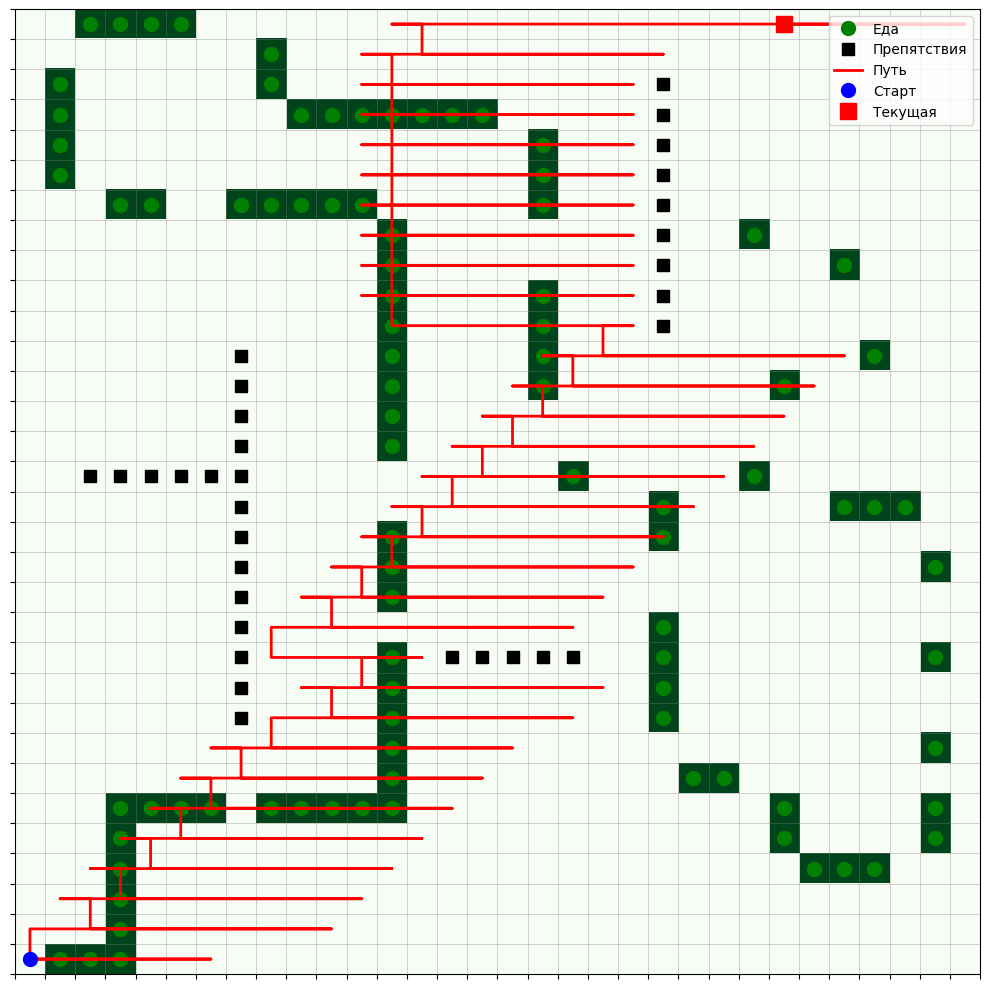

Путь: 4541 шагов


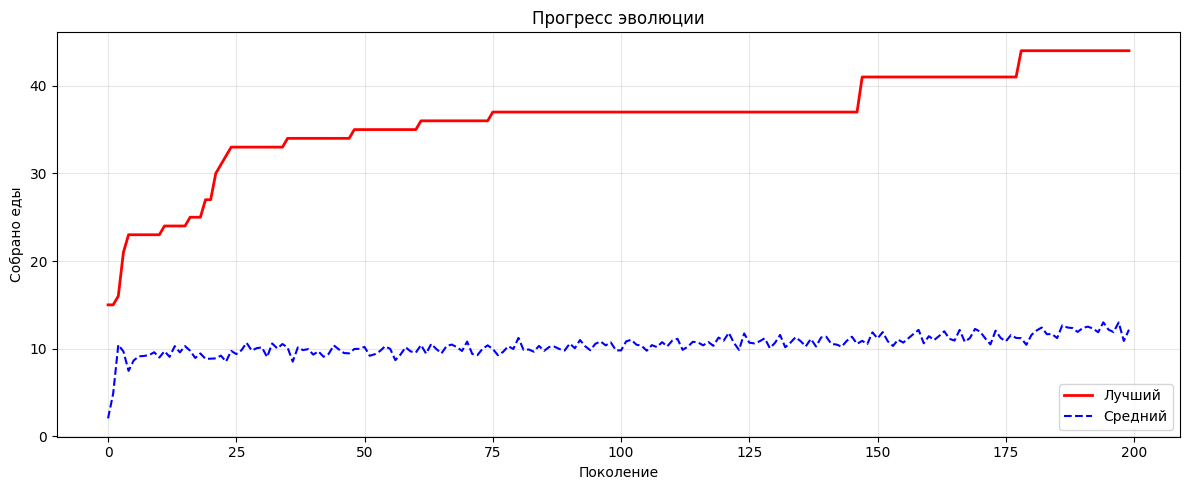

In [ ]:
results = run_evolution(
    num_states=34,
    population_size=490,
    generations=200,
    mutation_rate=0.07,
    elite_count=13,
    tournament_size=219,
    early_stop_threshold=90,
    sensor_type='current'
)

Поле: 32×32, еда: 90, старт: (31, 0)
Сенсор: neighbors
Gen   0: best= 18, mean= 2.31
Gen  10: best= 45, mean= 3.95
Gen  20: best= 66, mean= 5.88
Gen  30: best= 66, mean= 4.99
Gen  40: best= 72, mean= 5.46
Gen  50: best= 73, mean= 5.48
Gen  60: best= 75, mean= 4.66
Gen  70: best= 78, mean= 5.10
Gen  80: best= 84, mean= 4.02
Gen  90: best= 84, mean= 4.50
Gen 100: best= 84, mean= 4.44
Gen 110: best= 84, mean= 4.63
Gen 120: best= 84, mean= 4.21
Gen 130: best= 84, mean= 4.73
Gen 140: best= 84, mean= 4.61
Gen 150: best= 84, mean= 4.53
Gen 160: best= 84, mean= 4.42
Gen 170: best= 84, mean= 5.16
Gen 180: best= 84, mean= 4.29
Gen 190: best= 84, mean= 4.76

Результат: 84/90 еды (93.3%), путь: 3911 шагов

Таблица переходов (32 состояний, сенсор: neighbors):
S0+нет еды рядом → S4, •
S0+еда рядом → S9, •
S1+нет еды рядом → S14, ←
S1+еда рядом → S6, ←
S2+нет еды рядом → S17, →
S2+еда рядом → S15, ↑
S3+нет еды рядом → S10, ↓
S3+еда рядом → S16, ←
S4+нет еды рядом → S14, →
S4+еда рядом → S31, →
S5+нет

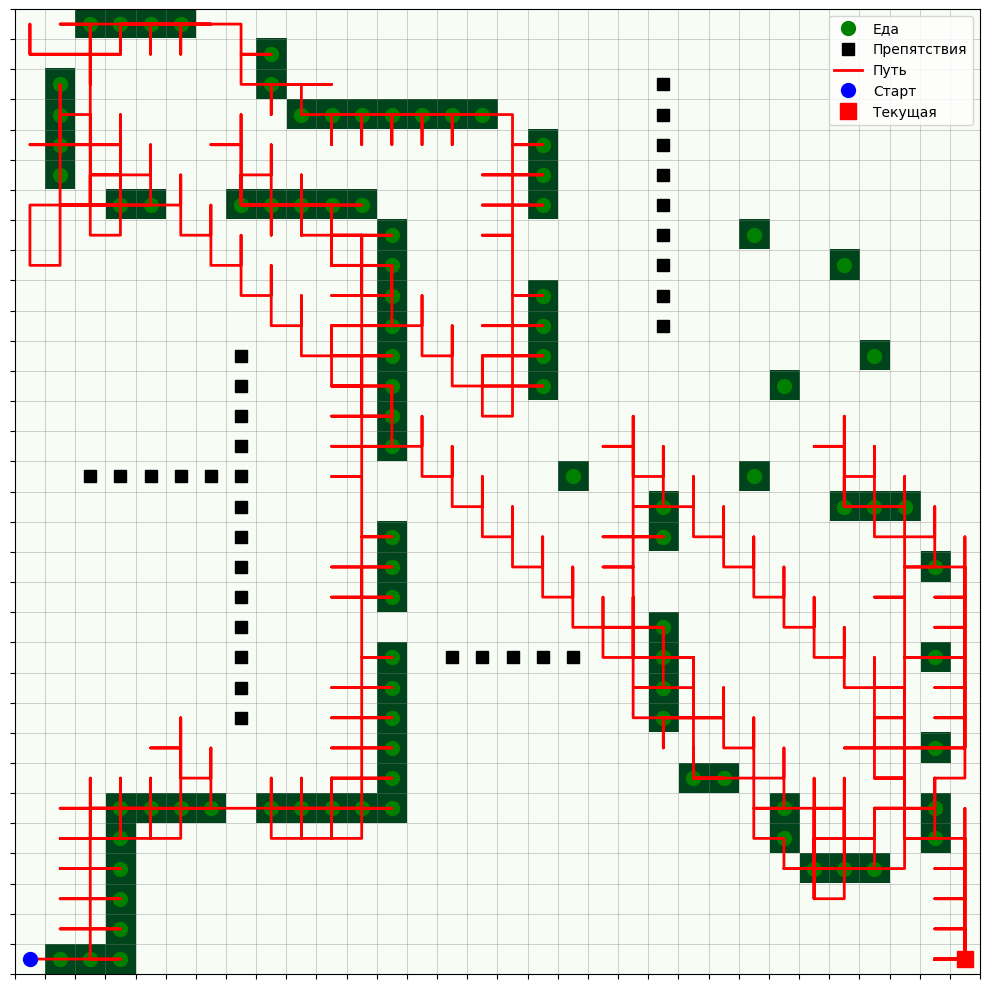

Путь: 3911 шагов


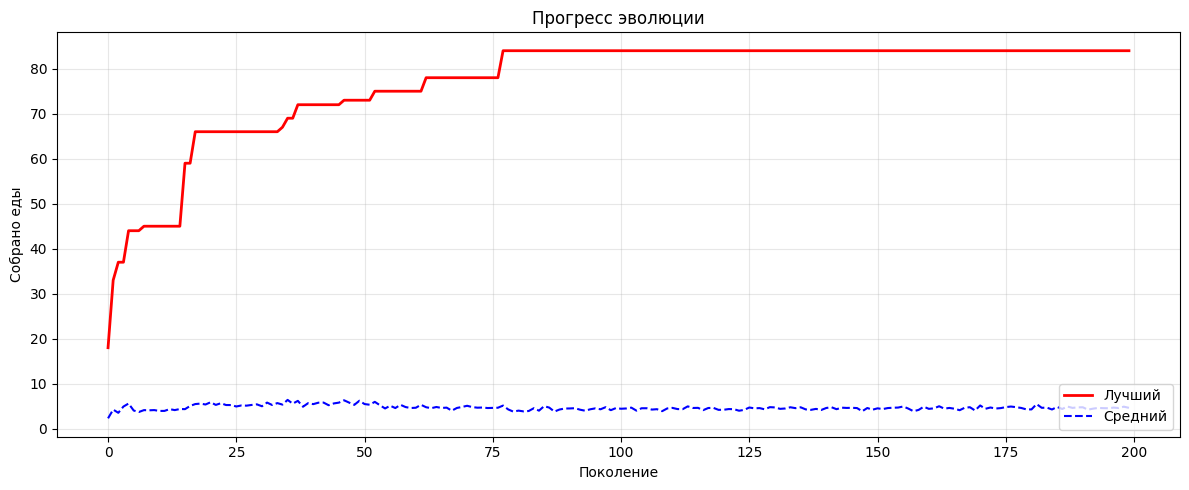

In [38]:
results = run_evolution(
    num_states=32,
    population_size=500,
    generations=200,
    mutation_rate=0.15,
    elite_count=6,
    tournament_size=500,
    early_stop_threshold=90,
    sensor_type='neighbors'
)

Поле: 32×32, еда: 90, старт: (31, 0)
Сенсор: current
Gen   0: best= 17, mean= 2.11
Gen  10: best= 29, mean=11.00
Gen  20: best= 30, mean=10.50
Gen  30: best= 33, mean=10.75
Gen  40: best= 33, mean=11.30
Gen  50: best= 34, mean=12.79
Gen  60: best= 34, mean=10.67
Gen  70: best= 34, mean=11.82
Gen  80: best= 34, mean=10.95
Gen  90: best= 34, mean=11.48
Gen 100: best= 35, mean=12.56
Gen 110: best= 35, mean=12.84
Gen 120: best= 35, mean=12.83
Gen 130: best= 35, mean=11.12
Gen 140: best= 35, mean=12.72
Gen 150: best= 35, mean=12.31
Gen 160: best= 35, mean=12.71
Gen 170: best= 35, mean=13.12
Gen 180: best= 35, mean=11.84
Gen 190: best= 35, mean=13.36

Результат: 35/90 еды (38.9%), путь: 4526 шагов

Таблица переходов (32 состояний, сенсор: current):
S0+пусто → S14, •
S0+еда → S10, →
S0+препят. → S11, ←
S1+пусто → S25, →
S1+еда → S18, ↑
S1+препят. → S10, ↓
S2+пусто → S13, ↓
S2+еда → S23, •
S2+препят. → S28, ←
S3+пусто → S24, ↓
S3+еда → S1, ↑
S3+препят. → S0, ↓
S4+пусто → S31, ↑
S4+еда → S26, ↑

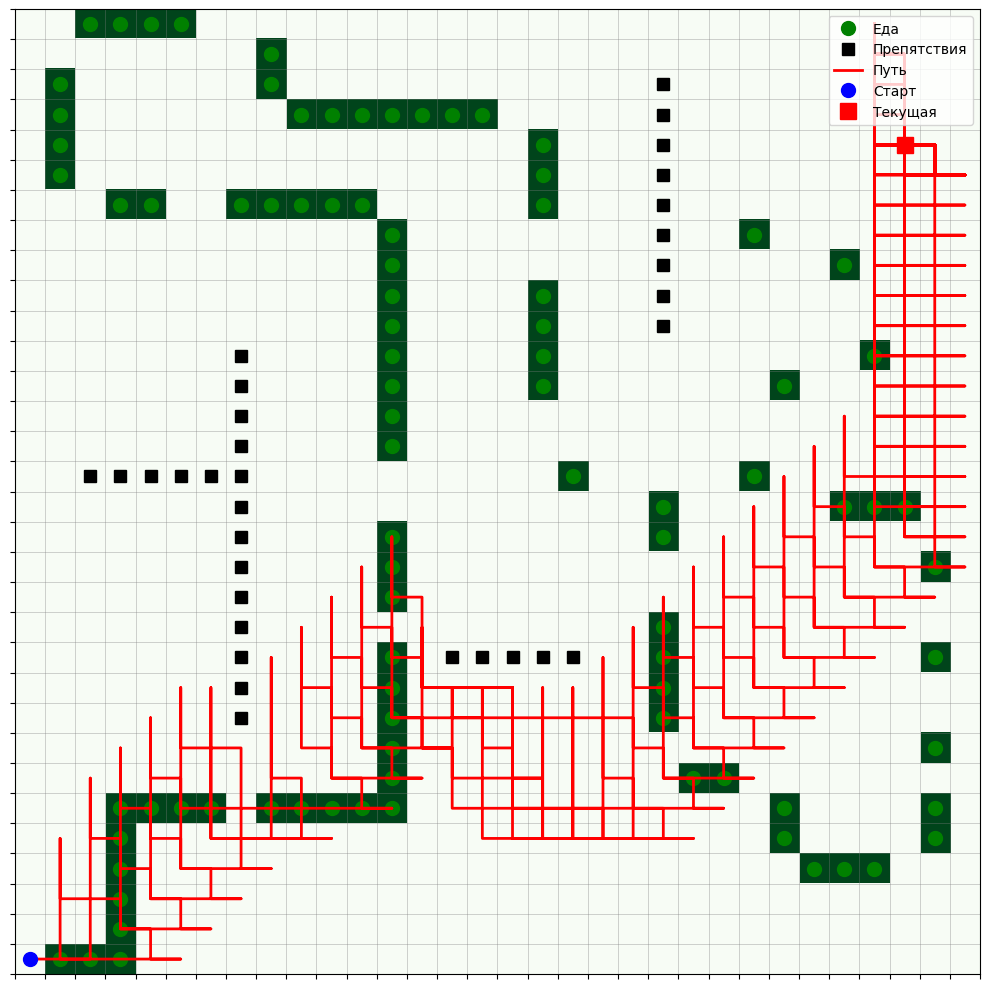

Путь: 4526 шагов


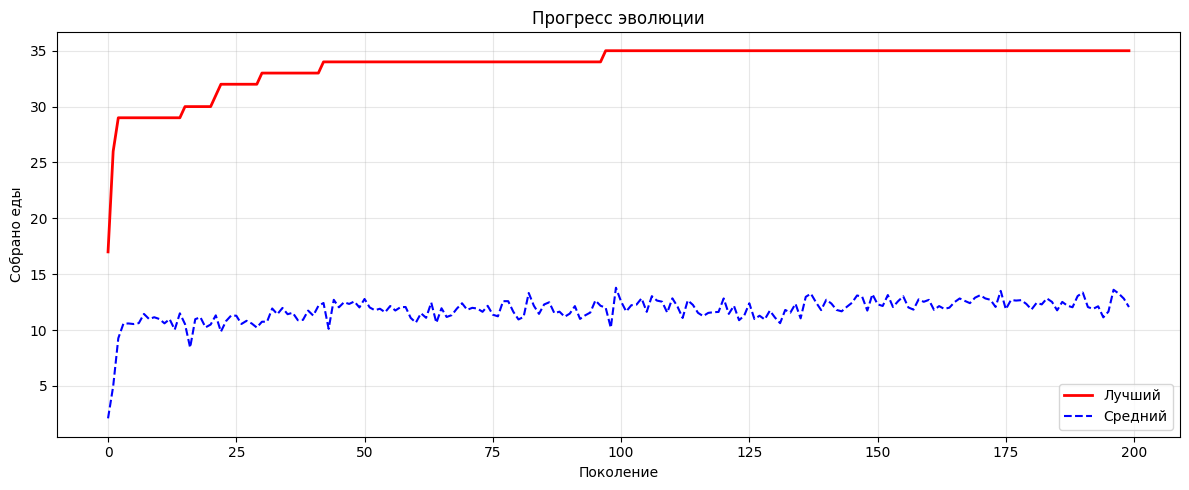

In [40]:
results = run_evolution(
    num_states=32,
    population_size=500,
    generations=200,
    mutation_rate=0.05,
    elite_count=6,
    tournament_size=250,
    early_stop_threshold=90,
    sensor_type='current'
)